# Milestone 2: Exploratory Data Analysis & Feature Engineering

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("visa_dataset.csv")

In [2]:
# Seasonal Feature 
df['case_received_date'] = pd.to_datetime(df['case_received_date'])
df['month'] = df['case_received_date'].dt.month

def get_season(month):
    if month in [12,1,2]:
        return 'Winter'
    elif month in [3,4,5]:
        return 'Spring'
    elif month in [6,7,8]:
        return 'Summer'
    else:
        return 'Fall'

df['season'] = df['month'].apply(get_season)

In [3]:
df.groupby('season')['processing_days'].mean()

season
Fall      203.757906
Spring    204.151982
Summer    199.979075
Winter    229.279616
Name: processing_days, dtype: float64

In [4]:
# country level processing analysis
df.groupby('country_of_citizenship')['processing_days'].mean().sort_values(ascending=False)

country_of_citizenship
NIGER                       634.500000
YUGOSLAVIA                  582.000000
KIRIBATI                    479.000000
MALI                        452.230769
GUATEMALA                   430.865385
                               ...    
RWANDA                      106.230769
TURKS AND CAICOS ISLANDS    103.000000
LIBERIA                      87.000000
CUBA                         21.000000
SINT MAARTEN                  0.000000
Name: processing_days, Length: 195, dtype: float64

In [5]:
df.groupby('class_of_admission')['processing_days'].mean()

class_of_admission
A-3           532.705882
A1/A2         283.168224
B-1           270.704485
B-2           294.146434
C-1           336.611111
C-3           177.571429
D-1           251.000000
E-1           211.752161
E-2           230.255487
E-3           167.146423
EWI           522.815625
F-1           202.362294
F-2           246.021008
G-1           237.000000
G-4           221.641791
G-5           308.324324
H-1A          176.181818
H-1B          206.492784
H-1B1         248.708633
H-2A          220.520833
H-2B          335.907407
H-3           184.480000
H-4           213.740319
I             244.418182
J-1           180.350746
J-2           168.518072
K-1           199.000000
L-1           203.942597
L-2           166.509485
M-1           214.722222
M-2           103.666667
N             145.000000
Not in USA    192.488140
O-1           185.559853
O-2           207.133333
O-3           147.000000
P-1           269.311111
P-2           117.000000
P-3           283.303030
P-4   

### Observation:
Processing time varies significantly across different visa classes.

### Interpretation:
Certain visa categories likely require more extensive documentation review, background verification, or employer validation, resulting in longer average processing durations.

### Impact:
Visa type (class_of_admission) is an important categorical feature and should be included in predictive modeling for accurate processing time estimation.

In [6]:
# processing office analysis
df.groupby('employer_state')['processing_days'].mean().sort_values(ascending=False)

employer_state
VIRGIN ISLANDS              1075.631579
VI                           984.357143
MISSISSIPPI                  396.032407
ALABAMA                      372.376328
NORTHERN MARIANA ISLANDS     364.200000
                               ...     
AR                           142.342105
MT                           142.162162
NH                           129.604545
MP                            90.326531
BC                            62.000000
Name: processing_days, Length: 112, dtype: float64

In [7]:
country_avg = df.groupby('country_of_citizenship')['processing_days'].mean()
df['country_avg_processing'] = df['country_of_citizenship'].map(country_avg)

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
selected_cols = [
    'processing_days',
    'employer_num_employees',
    'employer_yr_estab',
    'pw_amount_9089',
    'wage_offer_from_9089',
    'month'
]

df_small = df[selected_cols]

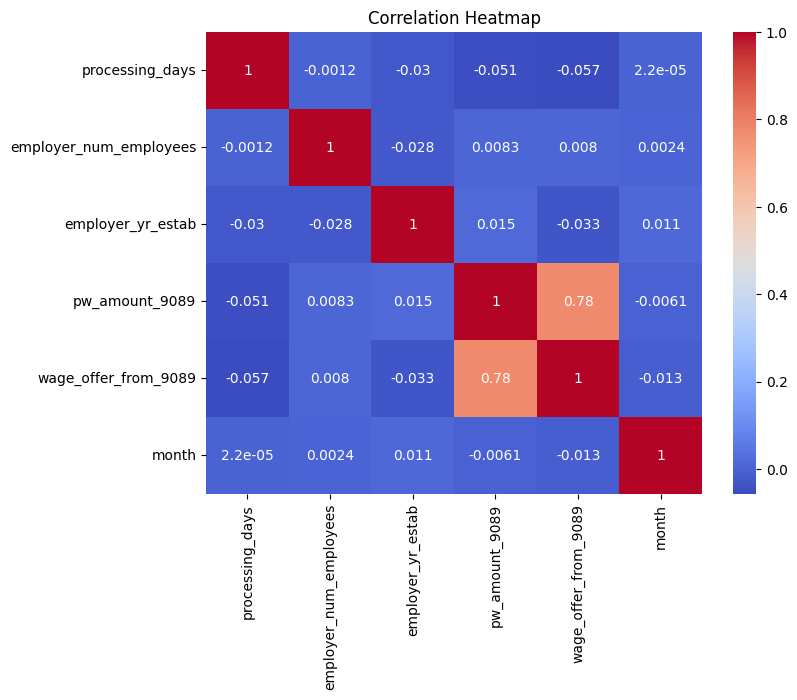

In [10]:
plt.figure(figsize=(8,6))
sns.heatmap(df_small.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## Key Insights from Exploratory Data Analysis

- Processing time varies significantly across visa types.
- Applicant country influences average approval duration.
- Seasonal variations suggest workload-related delays.
- Regional differences indicate administrative variability.
- Numeric wage and employer-related features show limited linear correlation with processing time.

These insights will guide feature selection and model development in Milestone 3.